# 1. Temperature Analysis within Local Climate Zones

The code will retrieve temperature measurements from ARPA meteorological stations situated in various regions of the metropolitan area of Milan. These stations are assigned to different local climate zones. Additionally, the code will analyze the data to check for any correlations between the stations within these local climate zones.



## 1.1. Import Libraries

All the necessary libraries have been imported to ensure the execution of the following codes. Additionally, we have imported the `ARPA functions`, which has been developed for manipulation of ARPA data. This function will remove outliers and aggregate the data in this repository.

In [1]:
# Filter warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Libraries 
import pandas as pd         
import numpy as np           
import scipy.stats as stats 
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.gofplots import qqplot
import ipywidgets as widgets 
from ipywidgets import ToggleButtons, Layout
import geopandas as gpd       
import rasterio                
from rasterio.plot import show  
import folium                  
from folium.plugins import MousePosition, Fullscreen  
from scipy.stats import kruskal
from scipy.stats import f_oneway
from shapely.geometry import Point 
import matplotlib.pyplot as plt              
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)  
import matplotlib.dates as mdates             
import seaborn as sns                         
from plotly import graph_objs as go          
import plotly.express as px   
from scikit_posthocs import posthoc_dunn
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import requests
import json

In [3]:
import ARPA_functions as f
%load_ext autoreload
%autoreload 2

## 2. Importing auxiliary data

Introducing a shapefile delineating the Metropolitan area of Milan, along with the dataframe of ARPA station locations within this region and their respective assigned local climate zones. This convergence is visually demonstrated on a map.
Additionally, an auxiliary dataframe retreived from **[Visual Crossing Database](https://www.visualcrossing.com/)** is imported (only 2022-2023). This dataframe will be used primarily to distinguish between daytime and nighttime measurments within a day.

In [4]:
cmm_gdf = gpd.read_file('CMM/CMM.shp')
milan_stations_lcz = pd.read_csv('LCZ.csv')

milan_stations_lcz

,Sensor ID,Name,Lat,Lon,LCZ
0,2001,Milano Lambrate,45.496780,9.257515,B_E
1,4058,Cinisello Balsamo Parco Nord,45.542665,9.205603,B_D
2,5897,Milano v.Brera,45.471656,9.189110,2
3,5903,Corsico v.le Italia,45.436109,9.097411,8_E
4,5909,Milano v.Juvara,45.473226,9.222315,5_2
5,5910,Lacchiarella v.Molise,45.324517,9.134517,5_6
6,5911,Milano v.Marche,45.496316,9.190934,"5_2,6"
7,5917,Rodano v.Turati,45.472580,9.353497,6
8,5920,Milano P.zza Zavattari,45.476063,9.141786,"5_2,8"
9,8162,Milano v.Feltre,45.491633,9.248738,B_5


In [6]:
m = folium.Map(location=[45.4642, 9.1900], zoom_start=10)

for index, row in milan_stations_lcz.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']], 
        radius=5,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.5,
        tooltip=f"{row['Name']} - ID: {row['Sensor ID']}" 
    ).add_to(m)

folium.GeoJson(
    cmm_gdf,
    name='Milan Boundaries',
    style_function=lambda x: {
        'color': 'red',
        'fillColor': 'none',
        'weight': 2
    }
).add_to(m)

MousePosition().add_to(m)

folium.plugins.Fullscreen(
    position="topright",
    title="Expand me",
    title_cancel="Exit me",
    force_separate_button=True,
).add_to(m)

folium.TileLayer('https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}', name='Google Satellite', attr='Google').add_to(m)

folium.TileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}', name='Esri Satellite', attr='Esri').add_to(m)

folium.LayerControl().add_to(m)
m

In [7]:
vcw_2023 = pd.read_csv('weather_data_Milano_2023_VCW.csv')
vcw_2022 = pd.read_csv('weather_data_Milano_2022_VCW.csv')
vcw_2022['datetime'] = pd.to_datetime(vcw_2022['datetime'], format='%d/%m/%Y')
vcw_2023['datetime'] = pd.to_datetime(vcw_2023['datetime'], format='%Y-%m-%d')
vcw_df = pd.concat([vcw_2022, vcw_2023], ignore_index=True)
#display(vcw_df)

## 3. Accessing the temperature data

The total temperature measurements since 2010 to 2023 were downloaded and exposed locally through [ROSE-API](http://github.com/Diuke/rose-api), a locally-developed OGC API Standardized interface.

It is important to consider that this service is not publicly accessible through the internet, but only through a local network. 

The complete set of measurements was downloaded from the following datasets:
- [2010 - 2020](https://www.dati.lombardia.it/Ambiente/Temperatura-dal-2011-al-2020/d4kj-kbpj/about_data)
- [Since 2021](https://www.dati.lombardia.it/Ambiente/Temperatura-dal-2021/w9wd-u6jh/about_data)

In [8]:
start_picker = widgets.DatetimePicker(description='Start Date:')
end_picker = widgets.DatetimePicker(description='End Date:')
widgets.VBox([start_picker, end_picker])

In [9]:
start_date = start_picker.value.replace(tzinfo=None)
end_date = end_picker.value.replace(tzinfo=None)

if end_date < start_date:
    print(f"The date interval is not valid. Please verify the end date is greater than the start date [{start_date}].")
else:
    print(f"The entered dates are valid.")

The entered dates are valid.


In [10]:
base_url = "http://10.78.3.85:8000/api/collections/temperature/items"
format = "geojson" #"json"
bbox = None
sensor_ids = "2001,4058,5897,5903,5909,5910,5911,5920,8162,12759,14742,5917"
limit = "50000"
datetime_filter = f"{start_date}/{end_date}"
skip_geometry = "true"

url = f"{base_url}?"
if format:
    url += f"f={format}&"

if datetime_filter:
    url += f"datetime={datetime_filter}&"

if bbox:
    url += f"bbox={bbox}&"

if sensor_ids:
    url += f"sensor_id__in={sensor_ids}&"

if sensor_ids:
    url += f"skipGeometry={skip_geometry}&"

if limit:
    url += f"limit={limit}"

print(url)

temperature_features = []
response = requests.get(url)
temp_data = response.json()
temperature_features += temp_data["features"]
next_page = True

while next_page:
    next_link = list(filter(lambda x: x["rel"] == "next",  temp_data["links"]))
    if len(next_link) > 0:
        next_link_url = next_link[0]["href"]
    else:
        break
    
    print(next_link_url)
    response = requests.get(next_link_url)
    temp_data = response.json()
    temperature_features += temp_data["features"]

http://10.78.3.85:8000/api/collections/temperature/items?f=geojson&datetime=2023-06-01 00:00:00/2023-06-30 23:59:00&sensor_id__in=2001,4058,5897,5903,5909,5910,5911,5920,8162,12759,14742,5917&skipGeometry=true&limit=50000
http://10.78.3.85:8000/api/collections/temperature/items?f=geojson&datetime=2023-06-01%2000:00:00/2023-06-30%2023:59:00&sensor_id__in=2001,4058,5897,5903,5909,5910,5911,5920,8162,12759,14742,5917&skipGeometry=true&limit=50000&offset=50000


In [11]:
properties_only = map(lambda x: x["properties"], temperature_features)
ARPA_df = gpd.GeoDataFrame(properties_only)
ARPA_df["value"] = ARPA_df["value"].astype(float)
ARPA_df = ARPA_df.sort_values("date")
new_column_names = {
    'sensor_id': 'Sensor ID',
    'date': 'DateTime',
    'value': 'Value'}
ARPA_df = ARPA_df.rename(columns=new_column_names)
new_order = ['Sensor ID', 'DateTime', 'Value']
df_interval = ARPA_df[new_order]
df_interval['DateTime'] = pd.to_datetime(df_interval['DateTime'])
df_interval

,Sensor ID,DateTime,Value
3235,12759,2023-06-01 00:00:00,18.61
3228,5910,2023-06-01 00:00:00,17.49
3229,2001,2023-06-01 00:00:00,18.80
3230,14742,2023-06-01 00:00:00,20.60
3231,5917,2023-06-01 00:00:00,18.60
...,...,...,...
3207,12759,2023-06-30 23:50:00,17.68
3206,2001,2023-06-30 23:50:00,18.20
3205,4058,2023-06-30 23:50:00,17.60
3210,14742,2023-06-30 23:50:00,18.40


## 4. Processing the Data

### 4.1. Outlier Removal

User can choose between two methods for  outlier removal:
- **[IQR](https://en.wikipedia.org/wiki/Interquartile_range)**
- **[Z-score](https://en.wikipedia.org/wiki/Standard_score)**

Given the non-normal characteristics of the data, we recommend using the IQR method. However, it is important to note that during the extraction of the raw data, invalid measurements are excluded from the database, and out-of-order values are rarely observed. Therefore, these methods might still identify some values as outliers even though they are not erroneous measurements. The decision to apply outlier removal is left to the user, as it will smooth out the data but may also discard some correct measurements.

In [12]:
outlier_methods = ['iqr', 'zscore'] # List of methods for removing outliers
checkboxes = [widgets.Checkbox(value=False, description=label) for label in outlier_methods]
output = widgets.VBox(children=checkboxes)
display(output)

In [13]:
selected_data = []
for i in range(0, len(checkboxes)):
    if checkboxes[i].value == True:
        selected_data = selected_data + [checkboxes[i].description]
print(selected_data)
if 'iqr' in selected_data:
    df_clean = df_interval.groupby('Sensor ID').apply(f.outlier_filter_iqr)
    print('Removed outliers using IQR')
if 'zscore' in selected_data:
    df_clean = f.outlier_filter_zscore(df_interval, df_interval['Sensor ID'].unique())
    print('Removed outliers using zscore')
if selected_data == []:
    print('No outlier removal process is executed.')
    df_clean = df_interval
#df_clean

['iqr']
Removed outliers using IQR


In [14]:
nan2 = df_clean[pd.isna(df_clean['Value'])].reset_index(drop=True)
print(f"Number of outliers removed: {len(nan2)}")

Number of outliers removed: 0


### 4.2. Data Aggregation

User can choose the aggregation frequency of the raw data, which are recorded at 10-minute intervals. The notebook is primarily developed to identify relationships between temperature measurements with hourly aggregation. Therefore, the analysis section will not proceed if an aggregation frequency other than hourly is selected.

However, by choosinotherly aggregatison, you will be able to observe the trend in the diurnal temperature ran (if daily aggregation is chosen)ge and analyze the temperature distribution for each station through a box plot. 

In [15]:
tagg_w = widgets.ToggleButtons(
    options=['H', 'D', 'W', 'M', 'Y'],
    description='Frequency:',
    disabled=False,
    button_style='info',
    tooltips=['Hour', 'Day', 'Week', 'Month', 'Year'])
tagg_w

ToggleButtons(button_style='info', description='Frequency:', options=('H', 'D', 'W', 'M', 'Y'), tooltips=('Hou…

In [16]:
tagg = tagg_w.value
df_agg = f.aggregate_group_data(df_clean, tagg)
df_agg = df_agg.rename(columns={
    'count': 'Count',
    'min': 'Min',
    'max': 'Max',
    'mean': 'Mean',
    'median': 'Median',
    'std': 'StdDev'
})
df_agg

Number of sensors available in the dataframe:  12
Temporal aggregation: H


,Sensor ID,DateTime,Count,Min,Max,Mean,Median,StdDev
0,2001,2023-06-01 00:00:00,6,17.7,18.8,18.08,17.90,0.43
1,2001,2023-06-01 01:00:00,6,17.0,17.9,17.43,17.40,0.38
2,2001,2023-06-01 02:00:00,6,16.7,17.6,17.23,17.30,0.31
3,2001,2023-06-01 03:00:00,6,16.4,17.2,16.75,16.70,0.31
4,2001,2023-06-01 04:00:00,6,17.2,17.5,17.37,17.40,0.10
...,...,...,...,...,...,...,...,...
8635,14742,2023-06-30 19:00:00,6,18.8,18.8,18.80,18.80,0.00
8636,14742,2023-06-30 20:00:00,6,18.3,18.8,18.55,18.50,0.22
8637,14742,2023-06-30 21:00:00,6,18.3,18.5,18.43,18.45,0.08
8638,14742,2023-06-30 22:00:00,6,18.4,18.5,18.43,18.40,0.05


In [17]:
nan3 = df_agg[pd.isna(df_agg['Mean'])]
print(f"Number of aggregated data with no value: {len(nan3)}")

Number of aggregated data with no value: 218


In [18]:
run_code = input("Do you want to see the line chart of the data?: ").lower()

if run_code == "yes":

    custom_palette = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231','#911eb4', '#42d4f4', '#fabed4', '#9A6324', '#808000', '#2a3444', '#005e7b']
    fig = px.line(df_agg, x='DateTime', y='Mean', color='Sensor ID', markers=False, 
        color_discrete_sequence=custom_palette,
        title=f"Mean Temperature (°C) by Station - Aggregation Frequency: {tagg_w.value}",
        labels={'DateTime': 'Date', 'Value': 'Mean Temperature (°C)', 'Sensor ID': 'Sensor ID'},
        line_group='Sensor ID',
        hover_name='Sensor ID',
        hover_data={'Sensor ID': True},
    )
    fig.update_layout(height=1000, width=1400)
    fig.show()
else:
    print("Code execution skipped.")

Do you want to see the line chart of the data?:  no


Code execution skipped.


### 4.3. Defining Daytime-Nighttime Intervals

- **Daytime** intervals are defined as a 3-hour period that includes the hours with the highest frequency of peak temperature measurements during a month.
- **Nighttime** intervals are defined as a period starting 3 to 5 hours after the average sunset time of the month.

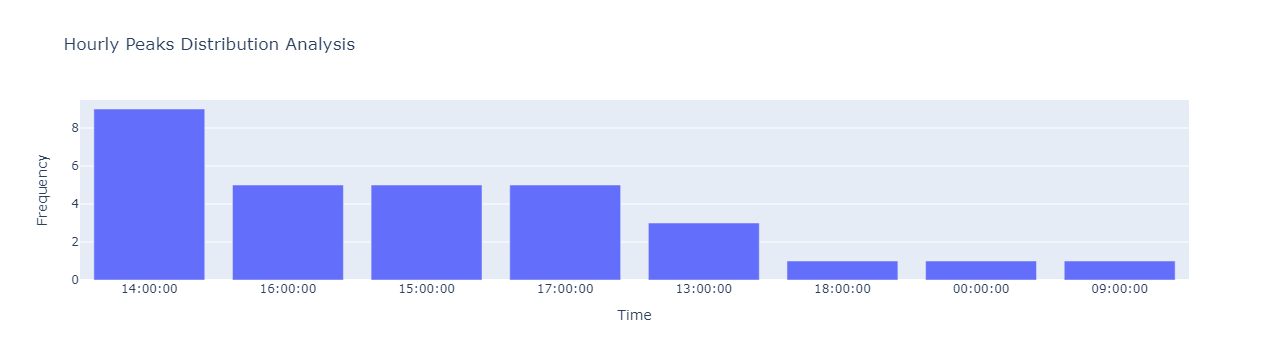

In [19]:
df_agg['Date'] = pd.to_datetime(df_agg['DateTime']).dt.date
df_agg['Time'] = pd.to_datetime(df_agg['DateTime']).dt.time
grouped = df_agg.groupby('Date')
max_v = grouped['Mean'].max()
max_t = grouped.apply(lambda x: x.loc[x['Mean'].idxmax(), 'Time'])
temp = pd.DataFrame({'Date': max_v.index, 'Max_Mean_Value': max_v.values, 'Time_of_Max_Mean': max_t.values})
time_counts = temp['Time_of_Max_Mean'].explode().value_counts()
fig = go.Figure([go.Bar(x=time_counts.index.astype(str), y=time_counts.values)])
fig.update_layout(
    title='Hourly Peaks Distribution Analysis',
    xaxis=dict(title='Time'),
    yaxis=dict(title='Frequency'),
    xaxis_tickangle=0
)
fig.show()

In [20]:
sd = start_picker.value.date() if start_picker.value else None
ed = end_picker.value.date() if end_picker.value else None
sd = pd.to_datetime(sd)
ed = pd.to_datetime(ed)
fdf = vcw_df[(vcw_df['datetime'] >= sd) & (vcw_df['datetime'] <= ed)]
fdf['sunset_time'] = fdf['sunset'].apply(lambda x: x.split('T')[1])
fdf['sunset_time'] = pd.to_datetime(fdf['sunset_time'])
fdf['sunset_seconds'] = fdf['sunset_time'].apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)
average_seconds = fdf['sunset_seconds'].mean()
average_time = pd.to_datetime(average_seconds, unit='s').time()

print("Average Sunset Time: {:02d}:{:02d}:{:02d}".format(average_time.hour, average_time.minute, average_time.second))

Average Sunset Time: 21:12:24


In [21]:
start_time_day_picker = widgets.TimePicker(description='Start Time for Day:', style={'description_width': 'initial'})
end_time_day_picker = widgets.TimePicker(description='End Time for Day:', style={'description_width': 'initial'})
start_time_night_picker = widgets.TimePicker(description='Start Time for Night:', style={'description_width': 'initial'})
end_time_night_picker = widgets.TimePicker(description='End Time for Night:', style={'description_width': 'initial'})
display(start_time_day_picker, end_time_day_picker, start_time_night_picker, end_time_night_picker)

TimePicker(value=None, description='Start Time for Day:', step=60.0, style=DescriptionStyle(description_width=…

TimePicker(value=None, description='End Time for Day:', step=60.0, style=DescriptionStyle(description_width='i…

TimePicker(value=None, description='Start Time for Night:', step=60.0, style=DescriptionStyle(description_widt…

TimePicker(value=None, description='End Time for Night:', step=60.0, style=DescriptionStyle(description_width=…

In [22]:
start_time_day = start_time_day_picker.value
end_time_day = end_time_day_picker.value
start_time_night = start_time_night_picker.value
end_time_night = end_time_night_picker.value

In [23]:
if tagg_w.value == 'H':
    df_agg['DateTime'] = pd.to_datetime(df_agg['DateTime'])
    df_agg['Date'] = df_agg['DateTime'].dt.date
    df_agg['Time'] = df_agg['DateTime'].dt.time
    df_H = df_agg[['Sensor ID', 'DateTime', 'Date', 'Time'] + [col for col in df_agg.columns if col not in ['Sensor ID', 'DateTime', 'Date', 'Time']]]

    day_data = df_H[(df_H['Time'] >= start_time_day) & (df_H['Time'] <= end_time_day)]
    
    if start_time_night > end_time_night:
        night_data = df_H[(df_H['Time'] >= start_time_night) | (df_H['Time'] <= end_time_night)]
    else:
        night_data = df_H[(df_H['Time'] >= start_time_night) & (df_H['Time'] <= end_time_night)]
    result = pd.concat([day_data, night_data])
else:
    print(f"Based on the data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

User can choose to continue with either all the measurements or only those within the defined intervals. It is recommended to select the second option, as hourly temperatures throughout the day exhibit high variability, which could introduce uncertainty into the final analysis.

In [24]:
if tagg_w.value == 'H':
    tagg_m = widgets.ToggleButtons(
        options=['24 Hours', 'Custom Hours'],
        description='Measurements:',
        disabled=False,
        button_style='info', # 'success', 'info', 'warning', 'danger' or ''
        tooltips=['Total 24 Hours', 'Partial time intervals during the day.']
    )
    display(tagg_m)
    
else:
    print(f"Based on the data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

ToggleButtons(button_style='info', description='Measurements:', options=('24 Hours', 'Custom Hours'), tooltips…

In [25]:
vcw_df['datetime'] = pd.to_datetime(vcw_df['datetime'], format='%Y-%m-%d').dt.date
if tagg_w.value == 'H':
    if tagg_m.value == '24 Hours':
        df_agg_meteo = pd.merge(df_H, vcw_df[['datetime', 'sunrise', 'sunset', 'icon']], 
                           how='inner', left_on='Date', right_on='datetime')

        df_agg_meteo['sunrise'] = pd.to_datetime(df_agg_meteo['sunrise'], format='%Y-%m-%dT%H:%M:%S')
        df_agg_meteo['sunset'] = pd.to_datetime(df_agg_meteo['sunset'], format='%Y-%m-%dT%H:%M:%S')

        df_agg_meteo['sunrise_time'] = df_agg_meteo['sunrise'].dt.time
        df_agg_meteo['sunset_time'] = df_agg_meteo['sunset'].dt.time
    
        df_agg_meteo['Day-Night'] = 'Unknown'
        df_agg_meteo['Day-Night'] = df_agg_meteo.apply(lambda row: 'Day' if row['Time'] >= row['sunrise_time'] and row['Time'] < row['sunset_time'] else 'Night', axis=1)

        df_agg_meteo.drop(columns=['datetime','sunrise', 'sunset', 'sunrise_time', 'sunset_time'], inplace=True)

    elif tagg_m.value == 'Custom Hours':
        df_agg_meteo = pd.merge(result, vcw_df[['datetime', 'sunrise', 'sunset', 'icon']], 
                           how='inner', left_on='Date', right_on='datetime')
        df_agg_meteo['sunrise'] = pd.to_datetime(df_agg_meteo['sunrise'], format='%Y-%m-%dT%H:%M:%S')
        df_agg_meteo['sunset'] = pd.to_datetime(df_agg_meteo['sunset'], format='%Y-%m-%dT%H:%M:%S')

        df_agg_meteo['sunrise_time'] = df_agg_meteo['sunrise'].dt.time
        df_agg_meteo['sunset_time'] = df_agg_meteo['sunset'].dt.time
    
        df_agg_meteo['Day-Night'] = 'Unknown'
        df_agg_meteo['Day-Night'] = df_agg_meteo.apply(lambda row: 'Day' if row['Time'] >= row['sunrise_time'] and row['Time'] < row['sunset_time'] else 'Night', axis=1)

        df_agg_meteo.drop(columns=['datetime','sunrise', 'sunset', 'sunrise_time', 'sunset_time'], inplace=True)

elif tagg_w.value == 'D':
    for index, row in df_agg.iterrows():
        df_agg.at[index, 'Diurnal Range'] = row['Max'] - row['Min']
    df_agg['DateTime'] = df_agg['DateTime'].dt.date
    df_agg_meteo = pd.merge(df_agg, vcw_df[['datetime', 'icon']], 
                       how='inner', left_on='DateTime', right_on='datetime')
    df_agg_meteo.drop(columns=['datetime'], inplace=True)

elif tagg_w.value == 'W':
    df_agg_meteo = df_agg

elif tagg_w.value == 'M':
    df_agg['DateTime'] = df_agg['DateTime'].dt.strftime('%Y-%m')
    df_agg_meteo = df_agg
    
elif tagg_w.value == 'Y':
    df_agg['DateTime'] = df_agg['DateTime'].dt.year
    df_agg_meteo = df_agg

df_agg_meteo = pd.merge( milan_stations_lcz, df_agg_meteo, on='Sensor ID', how='inner')
df_agg_meteo

,Sensor ID,Name,Lat,Lon,LCZ,DateTime,Date,Time,Count,Min,Max,Mean,Median,StdDev,icon,Day-Night
0,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 14:00:00,2023-06-01,14:00:00,6,27.0,28.6,27.92,27.95,0.55,rain,Day
1,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 15:00:00,2023-06-01,15:00:00,6,28.5,29.3,28.77,28.70,0.28,rain,Day
2,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 16:00:00,2023-06-01,16:00:00,6,26.5,27.6,26.83,26.65,0.44,rain,Day
3,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 14:00:00,2023-06-02,14:00:00,6,27.9,29.5,28.65,28.65,0.65,rain,Day
4,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 15:00:00,2023-06-02,15:00:00,6,28.4,29.7,28.70,28.50,0.49,rain,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 01:00:00,2023-06-29,01:00:00,0,NaN,NaN,NaN,NaN,NaN,rain,Night
2156,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 02:00:00,2023-06-29,02:00:00,0,NaN,NaN,NaN,NaN,NaN,rain,Night
2157,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 00:00:00,2023-06-30,00:00:00,6,21.8,22.2,22.00,22.00,0.15,rain,Night
2158,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 01:00:00,2023-06-30,01:00:00,6,21.9,22.3,22.12,22.15,0.15,rain,Night


In [26]:
for index, row in df_agg_meteo.iterrows():
    station_name = row['Name']
    lcz = row['LCZ']
    new_value = f"{station_name} - {lcz}"
    df_agg_meteo.loc[index, 'Name_LCZ'] = new_value
df_agg_meteo

,Sensor ID,Name,Lat,Lon,LCZ,DateTime,Date,Time,Count,Min,Max,Mean,Median,StdDev,icon,Day-Night,Name_LCZ
0,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 14:00:00,2023-06-01,14:00:00,6,27.0,28.6,27.92,27.95,0.55,rain,Day,Milano Lambrate - B_E
1,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 15:00:00,2023-06-01,15:00:00,6,28.5,29.3,28.77,28.70,0.28,rain,Day,Milano Lambrate - B_E
2,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 16:00:00,2023-06-01,16:00:00,6,26.5,27.6,26.83,26.65,0.44,rain,Day,Milano Lambrate - B_E
3,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 14:00:00,2023-06-02,14:00:00,6,27.9,29.5,28.65,28.65,0.65,rain,Day,Milano Lambrate - B_E
4,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 15:00:00,2023-06-02,15:00:00,6,28.4,29.7,28.70,28.50,0.49,rain,Day,Milano Lambrate - B_E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 01:00:00,2023-06-29,01:00:00,0,NaN,NaN,NaN,NaN,NaN,rain,Night,Rho Scalo Fiorenza - Prato - E_8
2156,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 02:00:00,2023-06-29,02:00:00,0,NaN,NaN,NaN,NaN,NaN,rain,Night,Rho Scalo Fiorenza - Prato - E_8
2157,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 00:00:00,2023-06-30,00:00:00,6,21.8,22.2,22.00,22.00,0.15,rain,Night,Rho Scalo Fiorenza - Prato - E_8
2158,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 01:00:00,2023-06-30,01:00:00,6,21.9,22.3,22.12,22.15,0.15,rain,Night,Rho Scalo Fiorenza - Prato - E_8


By utilizing additional data from the Visual Crossing database, we can retrieve information on the general weather conditions for each day. User can select specific days for further analysis.

Subsequently, user can choose to continue the analysis for daytime and nighttime separately or together. We recommend conducting the analysis separately for each interval to obtain more precise and meaningful results.

In [27]:
if tagg_w.value in ['H', 'D']:
    icons_1 = df_agg_meteo['icon'].unique()
    checkboxes = []
    icon_counts = df_agg_meteo['icon'].value_counts()

    for icon in icons_1:
        checkbox = widgets.Checkbox(value=False, description=icon)
        checkboxes.append(checkbox)

        count_text = widgets.Text(value=str(icon_counts.get(icon, 0)), description='Count', disabled=True)
        display(widgets.HBox([checkbox, count_text]))

    print("Select icons to filter by:")
else:
    print(f"Based on the data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")


Select icons to filter by:


In [28]:
if tagg_w.value in ['H', 'D']:
    selected_icons_1 = [icons_1[i] for i, checkbox in enumerate(checkboxes) if checkbox.value]
    print(f"The list of selected icons: {selected_icons_1}\n")

    if selected_icons_1:
        df_agg_meteo_icon = df_agg_meteo[df_agg_meteo['icon'].isin(selected_icons_1)]
    else:
        df_agg_meteo_icon = pd.DataFrame(columns=df_agg_meteo.columns)
    print(f"Number of available measurments: {len(df_agg_meteo_icon)}\n")
    display(df_agg_meteo_icon)
else:
    print(f"Based on the data aggregation frequency [{tagg_w.value}], this section is not required and will be skipped.")

The list of selected icons: ['rain', 'partly-cloudy-day', 'clear-day']

Number of available measurments: 2160



,Sensor ID,Name,Lat,Lon,LCZ,DateTime,Date,Time,Count,Min,Max,Mean,Median,StdDev,icon,Day-Night,Name_LCZ
0,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 14:00:00,2023-06-01,14:00:00,6,27.0,28.6,27.92,27.95,0.55,rain,Day,Milano Lambrate - B_E
1,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 15:00:00,2023-06-01,15:00:00,6,28.5,29.3,28.77,28.70,0.28,rain,Day,Milano Lambrate - B_E
2,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 16:00:00,2023-06-01,16:00:00,6,26.5,27.6,26.83,26.65,0.44,rain,Day,Milano Lambrate - B_E
3,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 14:00:00,2023-06-02,14:00:00,6,27.9,29.5,28.65,28.65,0.65,rain,Day,Milano Lambrate - B_E
4,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 15:00:00,2023-06-02,15:00:00,6,28.4,29.7,28.70,28.50,0.49,rain,Day,Milano Lambrate - B_E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 01:00:00,2023-06-29,01:00:00,0,NaN,NaN,NaN,NaN,NaN,rain,Night,Rho Scalo Fiorenza - Prato - E_8
2156,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 02:00:00,2023-06-29,02:00:00,0,NaN,NaN,NaN,NaN,NaN,rain,Night,Rho Scalo Fiorenza - Prato - E_8
2157,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 00:00:00,2023-06-30,00:00:00,6,21.8,22.2,22.00,22.00,0.15,rain,Night,Rho Scalo Fiorenza - Prato - E_8
2158,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 01:00:00,2023-06-30,01:00:00,6,21.9,22.3,22.12,22.15,0.15,rain,Night,Rho Scalo Fiorenza - Prato - E_8


In [29]:
if tagg_w.value in ['H']:
    icons_2= df_agg_meteo_icon['Day-Night'].unique()

    checkboxes = [widgets.Checkbox(value=False, description=daynight) for daynight in icons_2]

    print("Select Day-Night measurements to filter by:")
    output = widgets.VBox(children=checkboxes)
    display(output)
else:
     print(f"Based on the data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

Select Day-Night measurements to filter by:


In [34]:
if tagg_w.value in ['H']:
    selected_icons_2 = [icons_2[i] for i, checkbox in enumerate(checkboxes) if checkbox.value]
    print(f"The list of selected icons: {selected_icons_2}\n")

    if selected_icons_2:
        df_agg_meteo_dn = df_agg_meteo_icon[df_agg_meteo_icon['Day-Night'].isin(selected_icons_2)]
    else:
        df_agg_meteo_dn = pd.DataFrame(columns=df_agg_meteo_icon.columns)
    print(f"Number of available measurments: {len(df_agg_meteo_dn)}\n")
    display(df_agg_meteo_dn)
else:
     print(f"Based on the he data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

The list of selected icons: ['Day']

Number of available measurments: 1080



,Sensor ID,Name,Lat,Lon,LCZ,DateTime,Date,Time,Count,Min,Max,Mean,Median,StdDev,icon,Day-Night,Name_LCZ
0,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 14:00:00,2023-06-01,14:00:00,6,27.0,28.6,27.92,27.95,0.55,rain,Day,Milano Lambrate - B_E
1,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 15:00:00,2023-06-01,15:00:00,6,28.5,29.3,28.77,28.70,0.28,rain,Day,Milano Lambrate - B_E
2,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-01 16:00:00,2023-06-01,16:00:00,6,26.5,27.6,26.83,26.65,0.44,rain,Day,Milano Lambrate - B_E
3,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 14:00:00,2023-06-02,14:00:00,6,27.9,29.5,28.65,28.65,0.65,rain,Day,Milano Lambrate - B_E
4,2001,Milano Lambrate,45.496780,9.257515,B_E,2023-06-02 15:00:00,2023-06-02,15:00:00,6,28.4,29.7,28.70,28.50,0.49,rain,Day,Milano Lambrate - B_E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 15:00:00,2023-06-29,15:00:00,6,28.7,29.7,29.05,29.00,0.38,rain,Day,Rho Scalo Fiorenza - Prato - E_8
2066,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-29 16:00:00,2023-06-29,16:00:00,6,28.3,29.3,28.73,28.60,0.36,rain,Day,Rho Scalo Fiorenza - Prato - E_8
2067,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 14:00:00,2023-06-30,14:00:00,6,19.0,19.4,19.25,19.25,0.15,rain,Day,Rho Scalo Fiorenza - Prato - E_8
2068,14742,Rho Scalo Fiorenza - Prato,45.517811,9.087923,E_8,2023-06-30 15:00:00,2023-06-30,15:00:00,6,19.4,19.8,19.55,19.55,0.15,rain,Day,Rho Scalo Fiorenza - Prato - E_8


In [35]:
if tagg_w.value == 'H':
    df_agg_meteo = df_agg_meteo_dn
elif tagg_w.value == 'D':
    df_agg_meteo = df_agg_meteo_icon
else:
    print("Please skip this cell!")

## 5. Analysis

In this section, after presenting the data distribution and statistics in the initial cells, you have the option to conduct a statistical test to compare different stations and determine if there are significant differences in their temperature readings.

The first step is to check for the prerequisite conditions of `ANOVA`. This involves conducting normality tests. If the data passes these tests, we then check for homogeneity of variances. If all conditions are satisfied, we can proceed with ANOVA and subsequently performm `Tukey's test` if applicable.

If the conditions for ANOVA are not met, we can use them `Kruskal wallis test`, which is a non-parametric alternative to ANOVA. If necessary, we can then conduct `Dunn's test` as a post-hoc analysis.

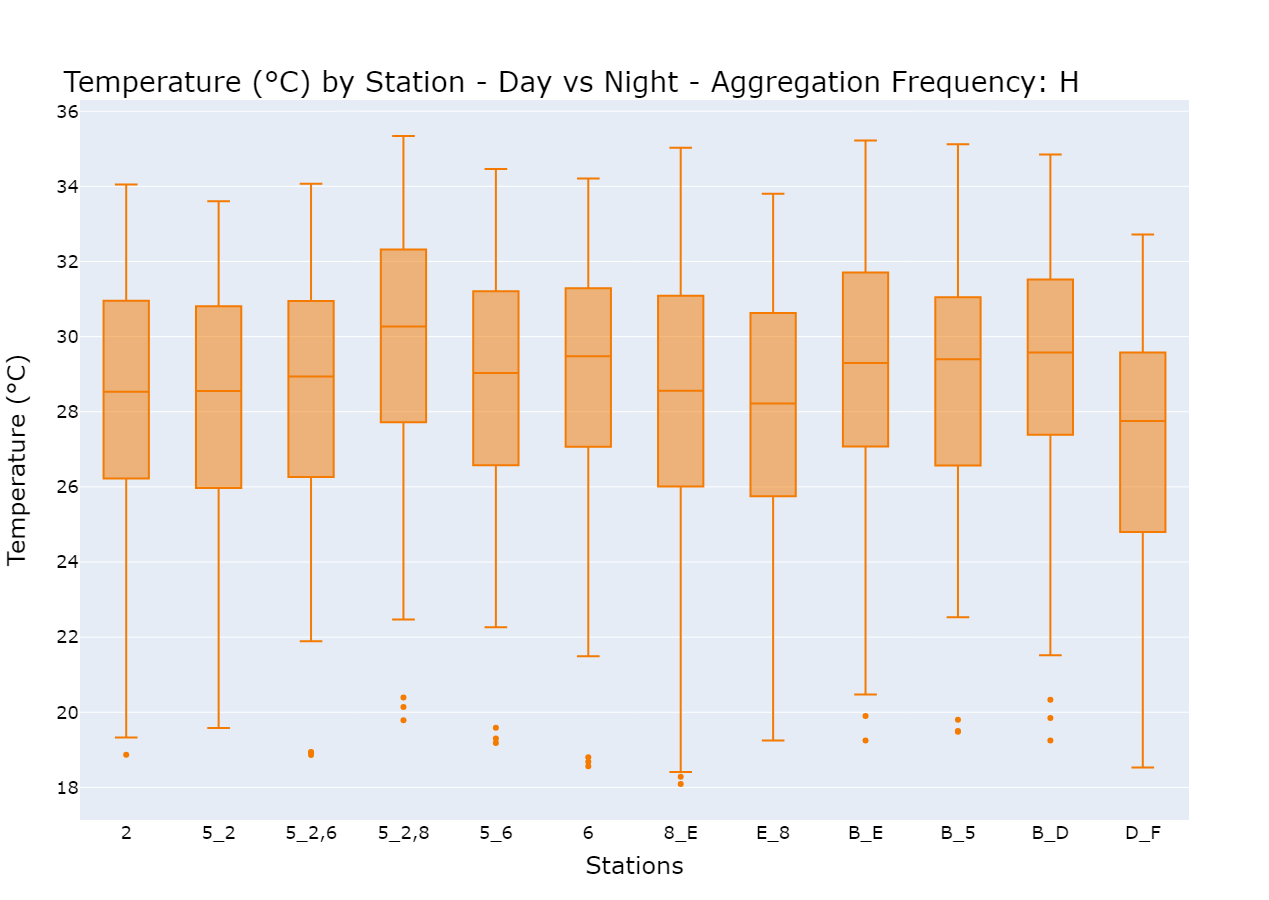

In [36]:
if tagg_w.value == 'H':
    day_data = df_agg_meteo[df_agg_meteo['Day-Night'] == 'Day']
    night_data = df_agg_meteo[df_agg_meteo['Day-Night'] == 'Night']

    order_of_stations = ['2', '5_2', '5_2,6', '5_2,8', '5_6',
                        '6', '8_E', 'E_8', 'B_E', 'B_5',
                        'B_D', 'D_F']
    
    trace_day = go.Box(
        y=day_data['Mean'],
        x=day_data['LCZ'],
        name='Day', 
        marker_color='#f47a00'
    )
    trace_night = go.Box(
        y=night_data['Mean'],
        x=night_data['LCZ'],
        name='Night',
        marker_color='#082a54'
    )

    fig = go.Figure(data=[trace_day, trace_night])
    fig.update_layout(
        title=f"Temperature (°C) by Station - Day vs Night - Aggregation Frequency: {tagg_w.value}",
        xaxis_title='Stations',
        yaxis_title='Temperature (°C)',
        boxmode='group',
        xaxis=dict(categoryorder='array', categoryarray=order_of_stations),
        title_y=0.92,
        font=dict(
            size=20,
            color='black'
        ),
        xaxis_tickfont=dict(
            size=18,
            color='black'
        ),
        yaxis_tickfont=dict(
            size=18,
            color='black'
        ),
    )
    fig.update_layout(height=900, width=1200)
    fig.show()
else:
     print(f"Based on the he data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

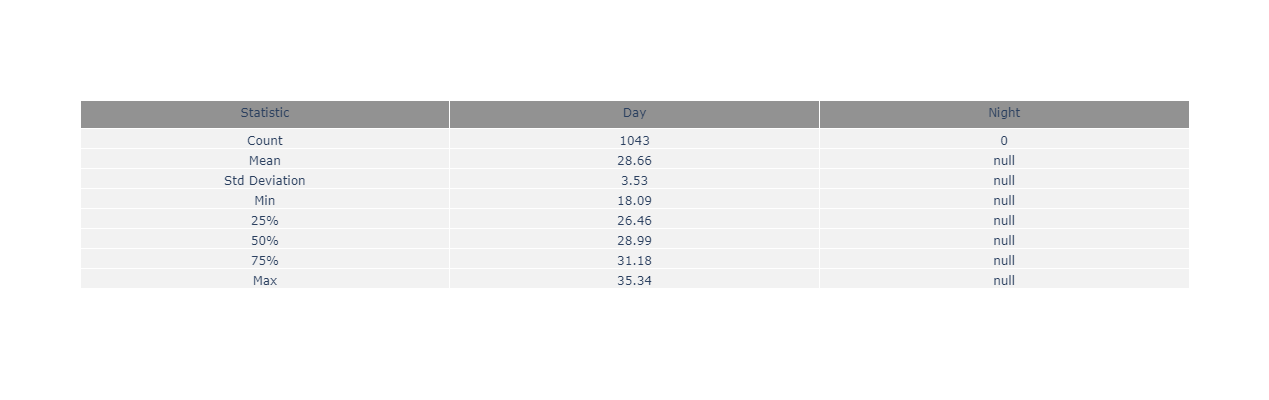

In [37]:
if tagg_w.value == 'H':
    stats_table = go.Table(
        header=dict(values=['Statistic', 'Day', 'Night'],
                    fill_color='#929292',
                    align='center'),
        cells=dict(values=[
            ['Count', 'Mean', 'Std Deviation', 'Min', '25%', '50%', '75%', 'Max'],
            [day_data['Mean'].count(), 
            round(day_data['Mean'].mean(), 2), 
            round(day_data['Mean'].std(), 2), 
            round(day_data['Mean'].min(), 2), 
            round(day_data['Mean'].quantile(0.25), 2), 
            round(day_data['Mean'].median(), 2), 
            round(day_data['Mean'].quantile(0.75), 2), 
            round(day_data['Mean'].max(), 2)],
            [night_data['Mean'].count(), 
            round(night_data['Mean'].mean(), 2), 
            round(night_data['Mean'].std(), 2), 
            round(night_data['Mean'].min(), 2), 
            round(night_data['Mean'].quantile(0.25), 2), 
            round(night_data['Mean'].median(), 2), 
            round(night_data['Mean'].quantile(0.75), 2), 
            round(night_data['Mean'].max(), 2)]
        ],
        fill_color='#F2F2F2',
        align='center'))

    fig = go.Figure(data=[stats_table])
    fig.update_layout(height=400, width=1000)
    fig.show()

else:
     print(f"Based on the he data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

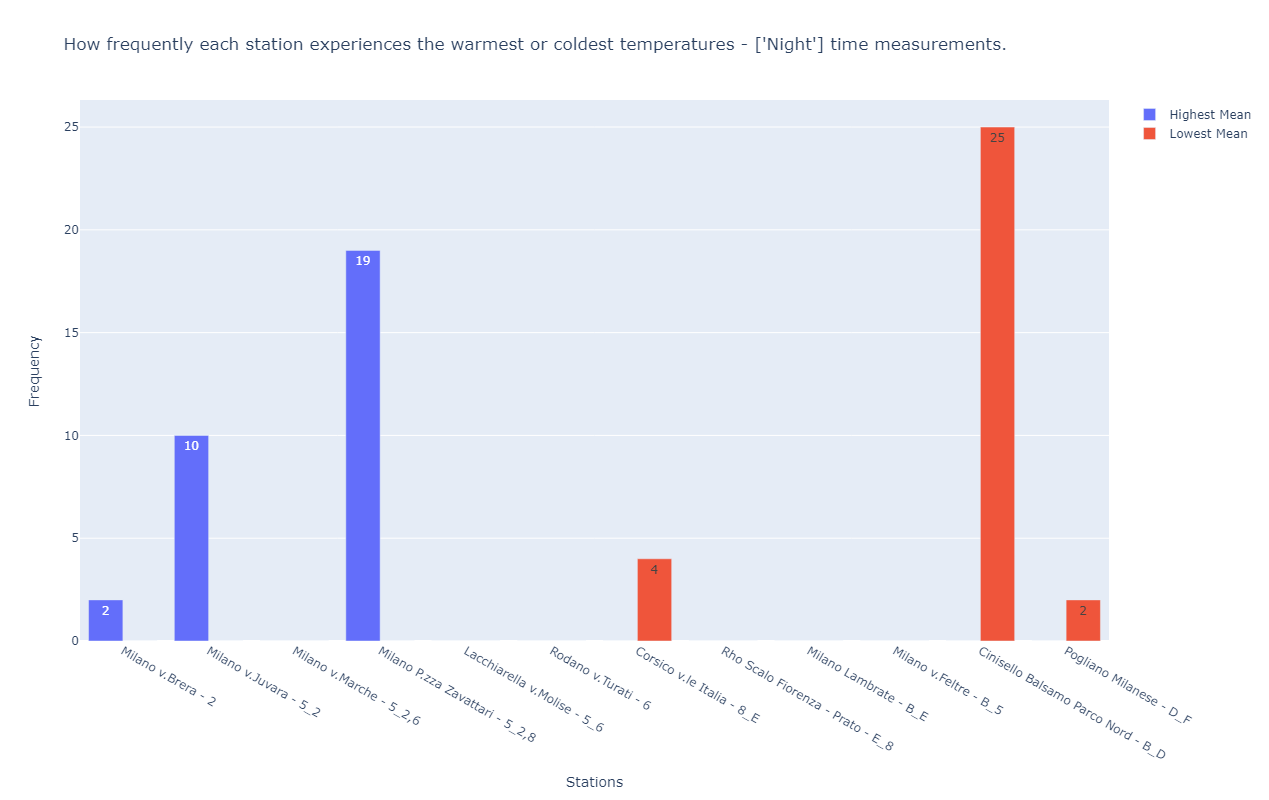

In [74]:
stations = df_agg_meteo['Name_LCZ'].unique()

station_counts = {station: {'Highest Mean': 0, 'Lowest Mean': 0} for station in stations}

order_of_stations = ['Milano v.Brera - 2', 'Milano v.Juvara - 5_2', 'Milano v.Marche - 5_2,6', 'Milano P.zza Zavattari - 5_2,8', 'Lacchiarella v.Molise - 5_6',
                        'Rodano v.Turati - 6', 'Corsico v.le Italia - 8_E', 'Rho Scalo Fiorenza - Prato - E_8', 'Milano Lambrate - B_E', 'Milano v.Feltre - B_5',
                        'Cinisello Balsamo Parco Nord - B_D', 'Pogliano Milanese - D_F']

if tagg_w.value == 'H':
    for date in df_agg_meteo['Date'].unique():
        df_date = df_agg_meteo[df_agg_meteo['Date'] == date]
        max_mean_station = df_date.loc[df_date['Mean'].idxmax()]['Name_LCZ']
        station_counts[max_mean_station]['Highest Mean'] += 1
        min_mean_station = df_date.loc[df_date['Mean'].idxmin()]['Name_LCZ']
        station_counts[min_mean_station]['Lowest Mean'] += 1

elif tagg_w.value != 'H':
    for date in df_agg_meteo['DateTime'].unique():
        df_date = df_agg_meteo[df_agg_meteo['DateTime'] == date]
        max_mean_station = df_date.loc[df_date['Mean'].idxmax()]['Name_LCZ']
        station_counts[max_mean_station]['Highest Mean'] += 1
        min_mean_station = df_date.loc[df_date['Mean'].idxmin()]['Name_LCZ']
        station_counts[min_mean_station]['Lowest Mean'] += 1

categories = order_of_stations
characteristics = ['Highest Mean', 'Lowest Mean']

data = []
for characteristic in characteristics:
    values = [station_counts[station][characteristic] for station in categories]
    text_values = [f'{value}' for value in values]
    bar_trace = go.Bar(
        x=categories,
        y=values,
        text=text_values,
        textposition='auto',  
        name=characteristic
    )
    
    data.append(bar_trace)

layout = go.Layout(
    title=f"How frequently each station experiences the warmest or coldest temperatures - {selected_icons_2} time measurements.",
    xaxis=dict(title='Stations'),
    yaxis=dict(title='Frequency'),
    barmode='group',  # Group bars
    width=1200,
    height=800,
)
fig_bar_chart = go.Figure(data=data, layout=layout)
fig_bar_chart.show()

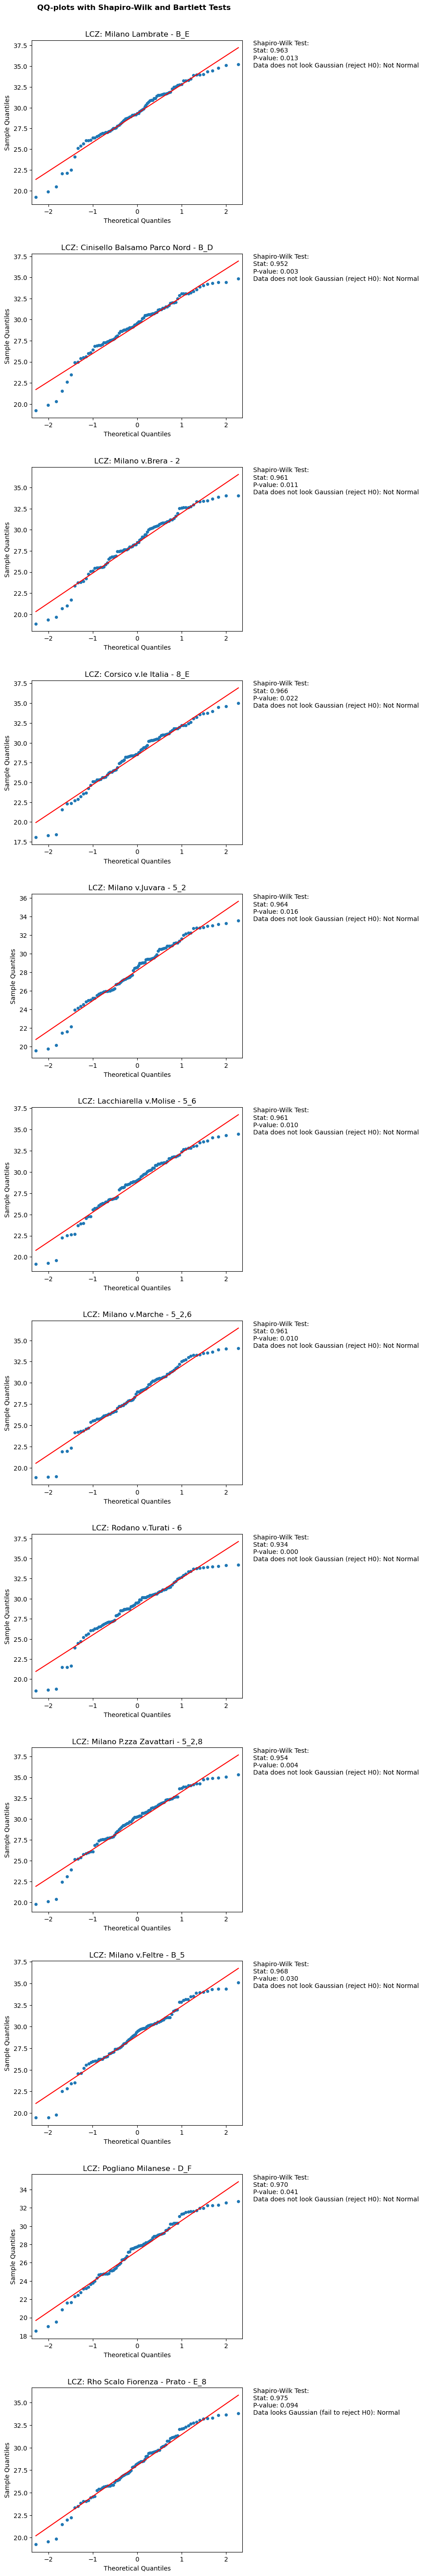

In [38]:
fig, axs = plt.subplots(len(df_agg_meteo['Name_LCZ'].unique()), 
                        figsize=(6, 6*len(df_agg_meteo['Name_LCZ'].unique())), 
                        gridspec_kw={'hspace': 0.3, 'wspace': 0.3})
fig.suptitle('QQ-plots with Shapiro-Wilk and Bartlett Tests', y=0.891, weight='bold')

for i, name in enumerate(df_agg_meteo['Name_LCZ'].unique()):
    axs[i].set_title('LCZ: ' + str(name), fontsize=12)
    data = df_agg_meteo.loc[df_agg_meteo['Name_LCZ'] == name, 'Mean'].dropna()
    qqplot(data, line='s', markersize=4, ax=axs[i])
    axs[i].set_xlabel('Theoretical Quantiles')
    axs[i].set_ylabel('Sample Quantiles')
    
    # Shapiro-Wilk Test
    alpha = 0.05
    shapiro_stat, shapiro_p_value = stats.shapiro(data)
    shapiro_result = 'Data looks Gaussian (fail to reject H0): Normal' if shapiro_p_value > alpha else 'Data does not look Gaussian (reject H0): Not Normal'
    
    axs[i].text(1.05, 1, f'Shapiro-Wilk Test:\nStat: {shapiro_stat:.3f}\nP-value: {shapiro_p_value:.3f}\n{shapiro_result}',
                transform=axs[i].transAxes, fontsize=10, verticalalignment='top')

plt.show()

In [39]:
tagg_n = widgets.ToggleButtons(
    options=['Normal', 'Not-Normal'],
    description='Distribution:',
    disabled=False,
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    tooltips=['The data have a normal distribution', 'The data does not have a normal distribution.'])
tagg_n

ToggleButtons(button_style='info', description='Distribution:', options=('Normal', 'Not-Normal'), tooltips=('T…

In [42]:
if tagg_n.value == 'Normal':
    a = []
    for lcz in df_agg_meteo['Name_LCZ'].unique():
        df = df_agg_meteo['Mean'].loc[df_agg_meteo['Name_LCZ'] == lcz].dropna()
        a.append(np.array(df))

    bartlett_stat, bartlett_p_value = stats.bartlett(*a)
    alpha = 0.05

    if bartlett_p_value >= alpha:
        bartlett_result = 'Variances are approximately equal (fail to reject H0): Homoscedastic'
        bartlett_note = 'Homoscedastic'
    else:
        bartlett_result = 'Variances are not equal (reject H0): Heteroscedastic'
        bartlett_note = 'Heteroscedastic'
    
    print(f"Bartlett Test Statistic: {bartlett_stat:.3f}")
    print(f"Bartlett Test p-value: {bartlett_p_value:.3f}")
    print(bartlett_result)

else:
    print(f"Based on the distribution of the samples which are {tagg_n.value}, this step is not necessary.")

Based on the distribution of the samples which are Not-Normal, this step is not necessary.


In [43]:
flag = 0
if tagg_n.value == 'Normal' and bartlett_p_value >= 0.05:
    flag = 1
    temperature_measurements = {}
    for station in df_agg_meteo['Name_LCZ'].unique():
        measurements = df_agg_meteo[df_agg_meteo['Name_LCZ'] == station]['Mean']
        measurements = measurements.dropna().tolist()  # Remove NaN values
        temperature_measurements[station] = measurements

    # Perform the ANOVA test
    anova_statistic, p_value = f_oneway(*temperature_measurements.values())

    if p_value < 0.05:
        result = "Reject the null hypothesis: There are significant differences between the stations."
    else:
        result = "Fail to reject the null hypothesis: There are no significant differences between the stations."
        
    test_results = {
        "Test Statistic": f"{anova_statistic:.3f}",
        "P-value": f"{p_value:.3f}",
        "Result": [result]
    }

    ANOVA_test_results = pd.DataFrame(test_results)
    pd.set_option('display.max_colwidth', None)
    display(ANOVA_test_results)
    
elif tagg_n.value == 'Normal' and bartlett_p_value <= 0.05:
     print(f"Data is {bartlett_note}, tehrefore this test is not appropriate.")

elif tagg_n.value == 'Not-Normal':
     print(f"Based on the distribution of the samples which are {tagg_n.value}, this test is not appropriate.")

Based on the distribution of the samples which are Not-Normal, this test is not appropriate.


In [44]:
if flag == 1:
    
    # perform Tukey's test
    tukey = pairwise_tukeyhsd(endog = df_agg_meteo['Mean'].dropna(),
                              groups = df_agg_meteo['LCZ'].loc[df_agg_meteo.Mean.notna()],
                              alpha = 0.05)
    display(tukey.summary())

else:
    print(f"This step is not necessary and should be skipped.")

This step is not necessary and should be skipped.


In [45]:
if flag == 1:
    table = tukey.summary()
    table = pd.DataFrame(table)
    table.columns = ['group1', 'group2', 'meandiff', 'p-adj', 'lower', 'upper', 'reject']
    table = table.iloc[1:, :]
    table['group'] = table['group1'].astype(str)+' - '+table['group2'].astype(str)
    table1 = table[['lower', 'upper', 'group']]
    data_dict = {}
    data_dict['category'] = list(table1['group'].astype(str))
    data_dict['lower'] = list(table1['lower'].astype(str))
    data_dict['upper'] = list(table1['upper'].astype(str))
    dataset = pd.DataFrame(data_dict)
    dataset['category'] = dataset['category'].astype(str).tolist()
    dataset['lower'] = dataset['lower'].astype(float).round(2).tolist()
    dataset['upper'] = dataset['upper'].astype(float).round(2).tolist()
    plt.figure(figsize=(15, 20))
    for lower,upper,y in zip(dataset['lower'],dataset['upper'],range(len(dataset))):
        plt.plot((lower,upper),(y,y),'ro-',color='red', markersize=3.5, linewidth=1)
    plt.yticks(range(len(dataset)),list(dataset['category']))
    plt.grid(color='grey', linestyle='-', linewidth=0.3)
    plt.suptitle(f'95% family-wise confidence levels for {selected_icons_2} measurments:', y=0.9, fontsize = 18)

    plt.savefig("tukey's.png")
else:
    print(f"This step is not necessary and should be skipped.")

This step is not necessary and should be skipped.


In [46]:
if flag == 0:
    temperature_measurements = {}
    for station in df_agg_meteo['Name_LCZ'].unique():
        measurements = df_agg_meteo[df_agg_meteo['Name_LCZ'] == station]['Mean'].tolist()
        temperature_measurements[station] = measurements

    # Perform the Kruskal-Wallis test
    kruskal_statistic, p_value = kruskal(*temperature_measurements.values(), nan_policy='omit')

    if p_value < 0.05:
        result = "Reject the null hypothesis: There are significant differences between the stations."
    else:
        result = "Fail to reject the null hypothesis: There are no significant differences between the stations."

    test_results = {
        "Test Statistic": [kruskal_statistic],
        "P-value": [p_value],
        "Result": [result]
    }

    KWD_test_results = pd.DataFrame(test_results)
    pd.set_option('display.max_colwidth', None)
    display(KWD_test_results)

else:
    print(f"This step is not necessary and should be skipped.")

,Test Statistic,P-value,Result
0,39.269238,0.000048,Reject the null hypothesis: There are significant differences between the stations.


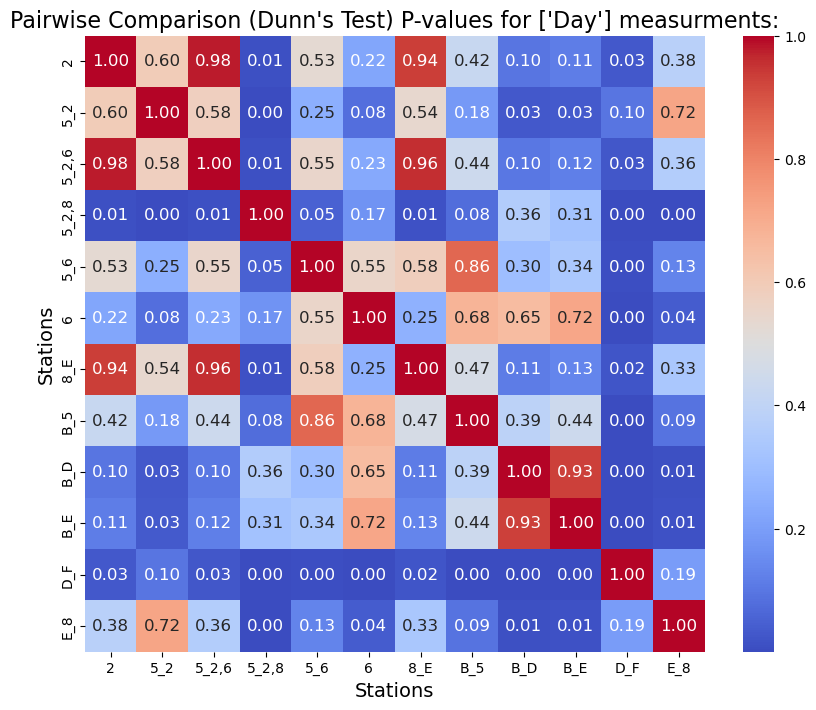

In [47]:
if flag == 0:
    # Perform Dunn's test
    dunn_results = posthoc_dunn(df_agg_meteo, val_col='Mean', group_col='LCZ')

    plt.figure(figsize=(10, 8))
    sns.heatmap(dunn_results, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, annot_kws={"fontsize": 12})
    plt.title(f"Pairwise Comparison (Dunn's Test) P-values for {selected_icons_2} measurments:", fontsize = 16)
    plt.xlabel("Stations", fontsize = 14)
    plt.ylabel("Stations", fontsize = 14)
    plt.savefig("dunn's_test.png")
    plt.show()
else:
    print(f"This step is not necessary and should be skipped.")

## 6. Distribution of Temperature Data  for Aggregations Other Than Hourly

- **Note:** If the `Daily` aggregation is chosen, User can visualize the data based on the `average daily temperatures` or observe the trend of the `diurnal temperature range`, which highlights the variation between the daily minimum and maximum temperatures. 

In [40]:
if tagg_w.value == 'D':
    tagg_r = widgets.ToggleButtons(
        options=['Daily Average', 'Daily Diurnal Range'],
        description='Range:',
        disabled=False,
        button_style='info', # 'success', 'info', 'warning', 'danger' or ''
        tooltips=['Consider the average daily temperature measurements', 'Consider the daily diurnal temperature range']
    )
    display(tagg_r)
    
else:
    print(f"Based on the data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

Based on the data aggregation frequency [H], this section is not required and should be skipped.


In [43]:
if tagg_w.value == 'D':
    if tagg_r.value == 'Daily Average':
        custom_palette = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231','#911eb4', '#42d4f4', '#fabed4', '#9A6324', '#808000', '#2a3444', '#005e7b']
        fig = px.line(df_agg_meteo, x='DateTime', y='Mean', color='Name_LCZ', markers=True, 
            color_discrete_sequence=custom_palette,
            title=f"Mean Temperature (°C) by Station - Aggregation Frequency: {tagg_w.value} - Range: {tagg_r.value}",
            labels={'DateTime': 'Date', 'Value': 'Mean Temperature (°C)', 'Name_LCZ': 'Stations'},
            line_group='Name_LCZ',
            hover_name='Name_LCZ',
            hover_data={'Name_LCZ': True, 'LCZ': True}, 
        )
        min_value = df_agg['Min'].min() - 5
        max_value = df_agg['Max'].max() + 5
        fig.update_layout(yaxis=dict(range=[min_value, max_value]))
        fig.update_traces(line_dash='dash', marker=dict(size=10))
        fig.update_layout(height=1000, width=1400)
        fig.show()
    elif tagg_r.value == 'Daily Diurnal Range':
        custom_palette = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231','#911eb4', '#42d4f4', '#fabed4', '#9A6324', '#808000', '#2a3444', '#005e7b']
        fig = px.scatter(df_agg_meteo, x='DateTime', y='Diurnal Range', color='Name_LCZ',
            color_discrete_sequence=custom_palette,
            title=f"Mean Temperature (°C) by Station - Aggregation Frequency: {tagg_w.value} - Range: {tagg_r.value}",
            labels={'DateTime': 'Date', 'Value': 'Mean Temperature (°C)', 'Name_LCZ': 'Stations'},
            hover_name='Name_LCZ',
            hover_data={'Name_LCZ': True, 'LCZ': True},
        )
        min_value = df_agg['Min'].min() - 5
        max_value = df_agg['Max'].max() + 5

        fig.update_layout(yaxis=dict(range=[min_value, max_value]))
        fig.update_traces(marker=dict(size=3))
        fig.update_layout(height=1000, width=1400)
        fig.show()
elif tagg_w.value in ['W', 'M', 'Y']:
    custom_palette = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231','#911eb4', '#42d4f4', '#fabed4', '#9A6324', '#808000', '#2a3444', '#005e7b']
    fig = px.line(df_agg_meteo, x='DateTime', y='Mean', color='Name_LCZ', markers=True, 
        color_discrete_sequence=custom_palette,
        title=f"Mean Temperature (°C) by Station - Aggregation Frequency: {tagg_w.value}",
        labels={'DateTime': 'Date', 'Value': 'Mean Temperature (°C)', 'Name_LCZ': 'Stations'},
        line_group='Name_LCZ',
        hover_name='Name_LCZ',
        hover_data={'Name_LCZ': True, 'LCZ': True},
    )
    min_value = df_agg['Min'].min() - 5
    max_value = df_agg['Max'].max() + 5
    fig.update_layout(yaxis=dict(range=[min_value, max_value]))
    fig.update_traces(line_dash='dash', marker=dict(size=10))
    fig.update_layout(height=1000, width=1400)
    fig.show()
else:
    print(f"Based on the data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

Based on the data aggregation frequency [H], this section is not required and should be skipped.


In [81]:
if tagg_w.value == 'D':
    if tagg_r.value == 'Daily Average':
        custom_palette = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
                          '#911eb4', '#42d4f4', '#fabed4', '#9A6324', '#808000', '#2a3444', '#005e7b']
        fig = px.box(df_agg_meteo, x='Name_LCZ', y='Mean', color='Name_LCZ', 
                      color_discrete_sequence=custom_palette,
                      title=f"Mean Temperature (°C) by Station - Aggregation Frequency: {tagg_w.value}",
                      labels={'Mean': 'Mean Temperature (°C)', 'Name_LCZ': 'Stations'},
                      hover_data={'Name_LCZ': True, 'LCZ': True} 
                      )
        fig.update_traces(opacity=1)
        fig.update_layout(height=1000, width=1400)
        fig.show()

    elif tagg_r.value == 'Daily Diurnal Range':
        custom_palette = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
                          '#911eb4', '#42d4f4', '#fabed4', '#9A6324', '#808000', '#2a3444', '#005e7b']
        fig = px.box(df_agg_meteo, x='Name_LCZ', y='Diurnal Range', color='Name_LCZ', 
                      color_discrete_sequence=custom_palette,
                      title=f"Mean Temperature (°C) by Station - Aggregation Frequency: {tagg_w.value}",
                      labels={'Mean': 'Mean Temperature (°C)', 'Name_LCZ': 'Stations'},
                      hover_data={'Name_LCZ': True, 'LCZ': True} 
                      )
        fig.update_traces(opacity=1)
        fig.update_layout(height=1000, width=1400)
        fig.show()
elif tagg_w.value in ['W', 'M', 'Y']:
    custom_palette = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
                      '#911eb4', '#42d4f4', '#fabed4', '#9A6324', '#808000', '#2a3444', '#005e7b']
    fig = px.box(df_agg_meteo, x='Name_LCZ', y='Mean', color='Name_LCZ', 
                    color_discrete_sequence=custom_palette,
                    title=f"Mean Temperature (°C) by Station - Aggregation Frequency: {tagg_w.value}",
                    labels={'Mean': 'Mean Temperature (°C)', 'Name_LCZ': 'Stations'},
                    hover_data={'Name_LCZ': True, 'LCZ': True} 
                    )
    fig.update_traces(opacity=1)
    fig.update_layout(height=1000, width=1400)
    fig.show()
else:
     print(f"Based on the the data aggregation frequency [{tagg_w.value}], this section is not required and should be skipped.")

Based on the he data aggregation frequency [H], this section is not required and should be skipped.
